In [1]:
import pickle

# Specify the path to your pickle file
file_path = r'/home/ddew0188/PHS/rPPG-Toolbox/runs/physnet/NBHR_SizeW128_SizeH128_ClipLength60_DataTypeDiffNormalized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_BackendYOLOv5_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len32_Median_face_boxTrue/saved_test_outputs/NBHR_NBHR_physnet_diffnormalized_Epoch14_NBHR_outputs.pickle'
# Open the file in binary read mode and load the object
with open(file_path, 'rb') as file:
    data = pickle.load(file)

# Now `data` contains the deserialized object from the pickle file
print(type(data))


<class 'dict'>


In [2]:
pred_dict = data["predictions"]
label_dict = data["labels"]

# Flatten and round predictions
pred_values = []
label_values = []
for subj_id, chunk_map in pred_dict.items():
    for chunk_idx, pred_tensor in chunk_map.items():
        # pred_tensor is e.g. torch.tensor(92.4) or similar
        pred_values.append(round(float(pred_tensor)))

        lab_tensor = label_dict[subj_id][chunk_idx]
        label_values.append(round(float(lab_tensor)))

print(pred_values)
print(label_values)


ValueError: only one element tensors can be converted to Python scalars

In [3]:
pred_values = []
label_values = []
for subj_id, chunk_map in pred_dict.items():
    for chunk_idx, pred_tensor in chunk_map.items():
        # pred_tensor is e.g. torch.tensor(92.4) or similar
        pred_values.append(round(float(pred_tensor)))

        lab_tensor = label_dict[subj_id][chunk_idx]
        # Take the mean of the tensor to get a scalar
        label_values.append(round(float(lab_tensor.mean())))

print(pred_values)
print(label_values)


[97, 96, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 99, 98, 99, 99, 98, 99, 99, 99, 99, 99, 99, 99, 96, 96, 96, 95, 96, 96, 96, 96, 96, 96, 94, 94, 94, 94, 94, 94, 94, 94, 94, 94, 93, 94, 94, 94, 92, 92, 92, 92, 92, 92, 92, 92, 92, 92, 95, 95, 95, 95, 95, 95, 95, 96, 96, 96, 96, 97, 97, 97, 97, 96, 96, 96, 96, 97, 97, 97, 95, 94, 91, 91, 91, 91, 91, 91, 91, 91, 91, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 96, 97, 97, 96, 93, 93, 93, 93, 93, 93, 93, 93, 96, 96, 94, 94, 94, 94, 94, 94, 94, 94, 93, 94, 94, 94, 94, 93, 94, 94, 94, 94, 94, 94, 97, 97, 97, 97, 97, 97, 97, 97, 96, 96, 97, 97, 97, 97, 97, 98, 97, 98, 98, 98, 97, 97, 97, 97, 98, 97, 97, 98, 97, 96, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 98, 99, 99, 99, 99, 98, 98, 98, 98, 98, 98, 98, 98, 99, 98, 98, 99, 99, 99, 99, 99, 99, 99, 94, 94, 93, 94, 94, 94, 93, 94, 94, 97, 97, 97, 97, 97, 97, 97, 97, 97, 96, 97, 97, 97, 97, 96, 97, 97, 96, 97, 96, 97, 96, 97, 97,

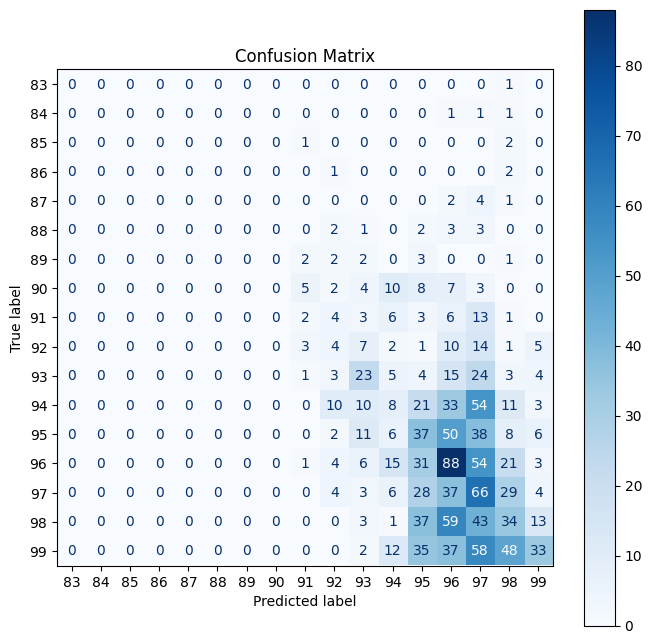

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Your prediction and ground truth lists
# pred_values = [...]
# label_values = [...]

# Convert to numpy arrays
y_pred = np.array(pred_values)
y_true = np.array(label_values)

# Get unique sorted labels (this ensures axis shows 95, 96, etc)
labels = np.unique(np.concatenate((y_true, y_pred)))

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


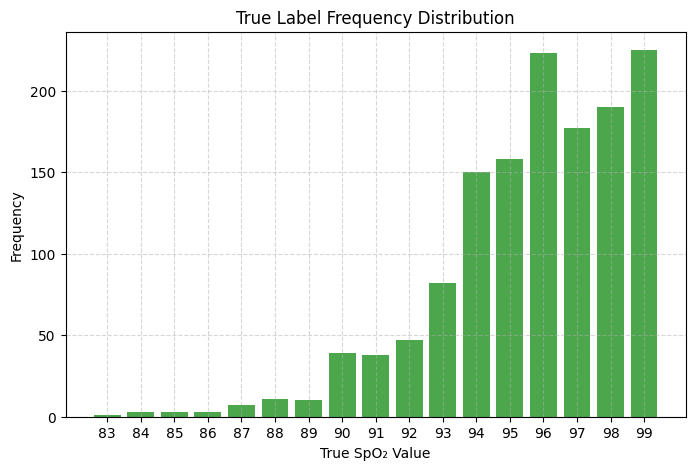

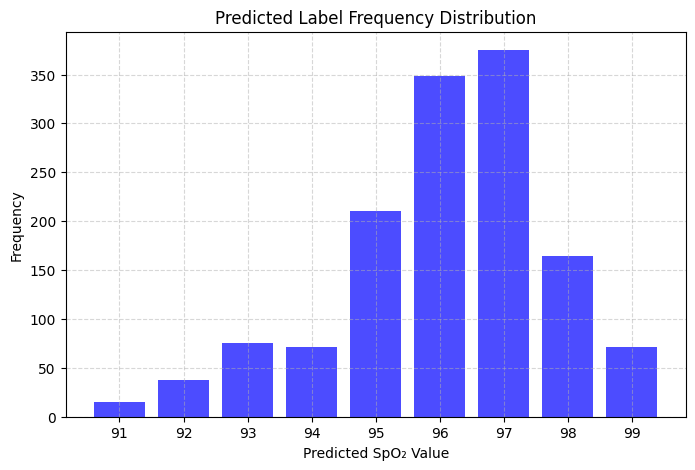

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you already have these lists
# pred_values = [...]
# label_values = [...]

# Convert to numpy arrays
y_pred = np.array(pred_values)
y_true = np.array(label_values)

# Unique values and their counts
true_labels, true_counts = np.unique(y_true, return_counts=True)
pred_labels, pred_counts = np.unique(y_pred, return_counts=True)

# Plot True Label Frequency
plt.figure(figsize=(8, 5))
plt.bar(true_labels, true_counts, color='green', alpha=0.7)
plt.xlabel('True SpO₂ Value')
plt.ylabel('Frequency')
plt.title('True Label Frequency Distribution')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(true_labels)  # Show all label ticks
plt.show()

# Plot Predicted Label Frequency
plt.figure(figsize=(8, 5))
plt.bar(pred_labels, pred_counts, color='blue', alpha=0.7)
plt.xlabel('Predicted SpO₂ Value')
plt.ylabel('Frequency')
plt.title('Predicted Label Frequency Distribution')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(pred_labels)  # Show all predicted label ticks
plt.show()


## Analysis

In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error


# Compute RMSE
rmse = np.sqrt(mean_squared_error(label_values, pred_values))

print("Test RMSE:", rmse)


Test RMSE: 0.9816015824491455


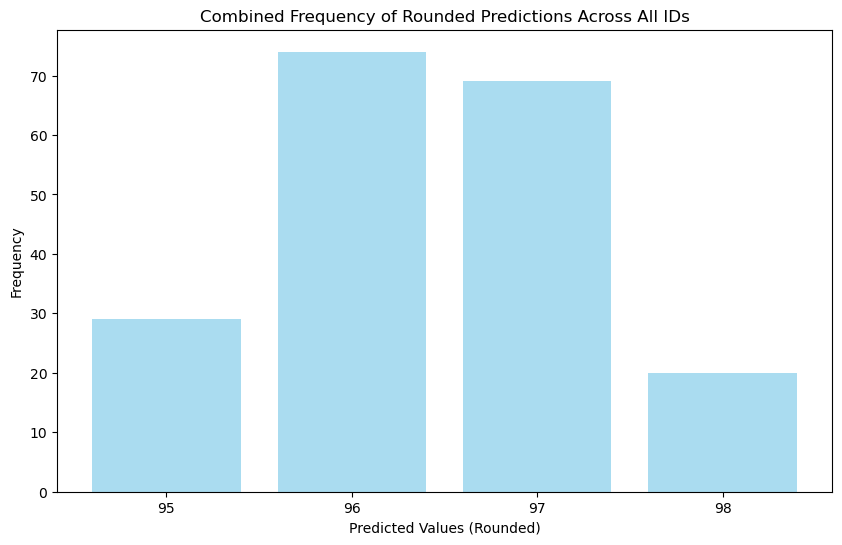

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data - replace this with your actual predictions dictionary
predictions = data["predictions"]

# Initialize a dictionary to store summed frequencies across all IDs
frequency_counts = {}

# Aggregate rounded predictions across all IDs
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        if rounded_pred in frequency_counts:
            frequency_counts[rounded_pred] += 1
        else:
            frequency_counts[rounded_pred] = 1

# Convert frequency_counts to lists for plotting
unique_values = list(frequency_counts.keys())
counts = list(frequency_counts.values())

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_values, counts, color='skyblue', alpha=0.7)

# Customize the plot
ax.set_xlabel('Predicted Values (Rounded)')
ax.set_ylabel('Frequency')
ax.set_title('Combined Frequency of Rounded Predictions Across All IDs')

# Set x-axis ticks if you know the range of values
plt.xticks(range(min(unique_values), max(unique_values) + 1))  # Modify range as per your data

# Show the plot
plt.show()


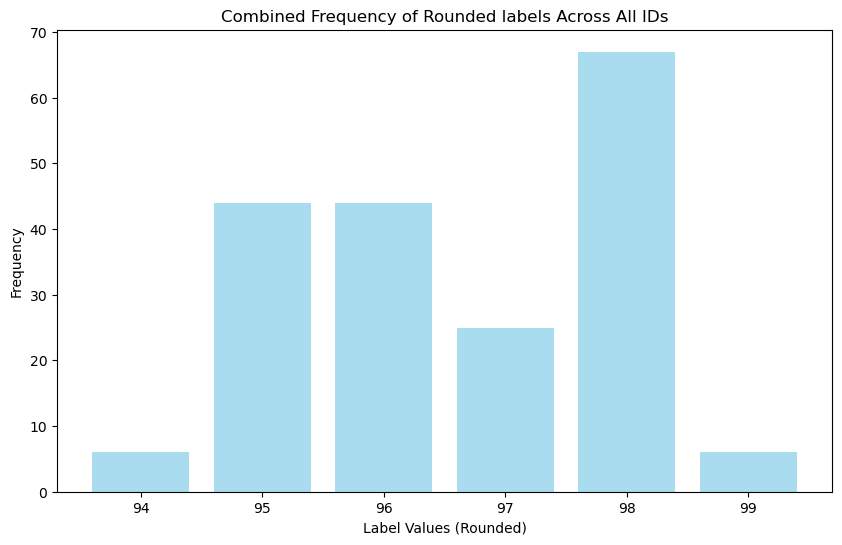

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data - label dictionary
predictions = data["labels"]

# Initialize a dictionary to store summed frequencies across all IDs
frequency_counts = {}

# Aggregate rounded predictions across all IDs
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        if rounded_pred in frequency_counts:
            frequency_counts[rounded_pred] += 1
        else:
            frequency_counts[rounded_pred] = 1

# Convert frequency_counts to lists for plotting
unique_values = list(frequency_counts.keys())
counts = list(frequency_counts.values())

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_values, counts, color='skyblue', alpha=0.7)

# Customize the plot
ax.set_xlabel('Label Values (Rounded)')
ax.set_ylabel('Frequency')
ax.set_title('Combined Frequency of Rounded labels Across All IDs')

# Set x-axis ticks if you know the range of values
plt.xticks(range(min(unique_values), max(unique_values) + 1))  # Modify range as per your data

# Show the plot
plt.show()

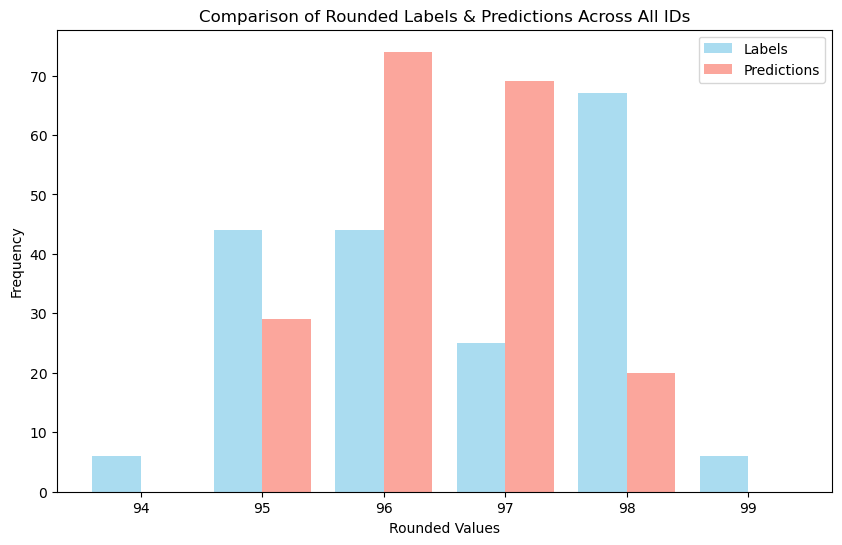

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
labels = data["labels"]
predictions = data["predictions"]

# Initialize dictionaries to store summed frequencies across all IDs
label_counts = {}
prediction_counts = {}

# Aggregate rounded labels
for preds in labels.values():
    for pred in preds.values():
        rounded_label = round(float(pred))
        label_counts[rounded_label] = label_counts.get(rounded_label, 0) + 1

# Aggregate rounded predictions
for preds in predictions.values():
    for pred in preds.values():
        rounded_pred = round(float(pred))
        prediction_counts[rounded_pred] = prediction_counts.get(rounded_pred, 0) + 1

# Get unique values (combined from both dictionaries)
unique_values = sorted(set(label_counts.keys()).union(set(prediction_counts.keys())))

# Create counts lists aligned with unique values
label_frequencies = [label_counts.get(val, 0) for val in unique_values]
prediction_frequencies = [prediction_counts.get(val, 0) for val in unique_values]

# Set bar width for side-by-side bars
bar_width = 0.4

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot labels and predictions side by side
ax.bar(np.array(unique_values) - bar_width/2, label_frequencies, width=bar_width, label="Labels", color='skyblue', alpha=0.7)
ax.bar(np.array(unique_values) + bar_width/2, prediction_frequencies, width=bar_width, label="Predictions", color='salmon', alpha=0.7)

# Customize the plot
ax.set_xlabel('Rounded Values')
ax.set_ylabel('Frequency')
ax.set_title('Comparison of Rounded Labels & Predictions Across All IDs')
ax.set_xticks(unique_values)  # Set x-axis ticks to match unique values
ax.legend()

# Show the plot
plt.show()


## Confusion Matrix

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Sample predictions and labels data - replace with your actual data
predictions = data["predictions"]
labels = data["labels"]

# Step 1: Flatten and round predictions and labels
pred_values = []
label_values = []

for key in predictions:
    for sub_key in predictions[key]:
        pred_values.append(round(predictions[key][sub_key].item()))
        label_values.append(round(labels[key][sub_key].item()))

# print(pred_values)
# print(label_values)
# Step 2: Calculate confusion matrix
cm = confusion_matrix(label_values, pred_values)

# Step 3: Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(label_values), yticklabels=np.unique(label_values))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

RuntimeError: a Tensor with 60 elements cannot be converted to Scalar